# **Install Modules**

In [1]:
!pip install torch torchvision albumentations opencv-python
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 119.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 72.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 79.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

# **Import Packages**

In [1]:
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# **Import dataset to local VRAM**

In [2]:
# !curl -L -o /content/drive/MyDrive/antsvisdrone-dataset.zip\
#   https://www.kaggle.com/api/v1/datasets/download/banuprasadb/visdrone-dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
drive_zip_path = "/content/drive/MyDrive/ants/visdrone-dataset.zip"
local_zip_path = "/content/visdrone-dataset.zip"
root_dir = "/content/visdrone-dataset"

#Check Existence of Dataset into VRAM
if os.path.exists(root_dir):
    print(f"Dataset Available in VRAM at {root_dir}")
else:
    print(f"Dataset Not Found in VRAM")
    if os.path.exists(drive_zip_path):
        print(f"Dataset Available in Google Drive at {drive_zip_path}")

        #Copy dataset to VRAM
        shutil.copyfile(drive_zip_path,local_zip_path)
        print(f"Dataset Copied to VRAM at {local_zip_path}")

        #Extract dataset in VRAM
        print("Extracting Dataset...")
        os.makedirs(root_dir,exist_ok=True)

        try:
            with zipfile.ZipFile(local_zip_path,'r') as zip_ref:
                zip_ref.extractall(root_dir)
            print("Dataset Extracted Successfully")
        except:
            print("Dataset Extraction Failed")

        os.remove(local_zip_path)
        print("Local Zip removed to free up spaces")
    else:
        print(f"Dataset Not Found in Google Drive")

print(f"\nroot_dir set to: {root_dir}")

Dataset Not Found in VRAM
Dataset Available in Google Drive at /content/drive/MyDrive/ants/visdrone-dataset.zip
Dataset Copied to VRAM at /content/visdrone-dataset.zip
Extracting Dataset...
Dataset Extracted Successfully
Local Zip removed to free up spaces

root_dir set to: /content/visdrone-dataset


# **Playground and Experiment with data(This is not part of actual code)**

In [5]:
def generate_tree(path, indent="", max_items=5):
    path = Path(path)

    if not path.exists():
        return

    # Display the current file or folder
    print(f"{indent}├── {path.name}/" if path.is_dir() else f"{indent}└── {path.name}")

    if path.is_dir():
        # Get all items and sort them
        items = list(sorted(path.iterdir()))

        for index, item in enumerate(items):
            # If we hit the limit, show how many are left and stop
            if index >= max_items:
                remaining = len(items) - max_items
                print(f"{indent}    └── ... (and {remaining} more items)")
                break

            # Recurse into subdirectories
            generate_tree(item, indent + "    ", max_items)

# --- Run it ---
# You can change max_items to any number you prefer
generate_tree("/content/visdrone-dataset", max_items=5)

├── visdrone-dataset/
    ├── VisDrone_Dataset/
        ├── VisDrone2019-DET-test-challenge/
            ├── images/
                └── 0000000_00098_d_0000001.jpg
                └── 0000000_01013_d_0000003.jpg
                └── 0000000_01619_d_0000004.jpg
                └── 0000000_02021_d_0000005.jpg
                └── 0000000_02309_d_0000006.jpg
                └── ... (and 1575 more items)
        ├── VisDrone2019-DET-test-dev/
            ├── images/
                └── 0000006_00159_d_0000001.jpg
                └── 0000006_00611_d_0000002.jpg
                └── 0000006_01111_d_0000003.jpg
                └── 0000006_01275_d_0000004.jpg
                └── 0000006_01659_d_0000004.jpg
                └── ... (and 1605 more items)
            ├── labels/
                └── 0000006_00159_d_0000001.txt
                └── 0000006_00611_d_0000002.txt
                └── 0000006_01111_d_0000003.txt
                └── 0000006_01275_d_0000004.txt
                └── 0000006_0165

In [6]:
import pandas as pd
from pathlib import Path

def create_visdrone_dataframe(root_path):
    root = Path(root_path)
    data = []

    # Mapping folder names to their split integer
    splits = {
        'VisDrone2019-DET-train': 0,
        'VisDrone2019-DET-val': 1,
        'VisDrone2019-DET-test-dev': 2,
        'VisDrone2019-DET-test-challenge': 2 # Adding this in case it's needed
    }

    for folder_name, split_id in splits.items():
        img_dir = root / folder_name / 'images'
        lbl_dir = root / folder_name / 'labels'

        if not img_dir.exists():
            continue

        for img_path in img_dir.glob('*.jpg'):
            # 1. Extract image_id (e.g., "0000006" from "0000006_00159_d_0000001.jpg")
            # .stem gives the filename without .jpg
            scene_id = img_path.stem.split('_')[0]

            # 2. Construct matching label path
            label_path = lbl_dir / (img_path.stem + '.txt')

            # 3. Append data (handling cases where labels might be missing)
            data.append({
                'scene_id': scene_id,
                'image_path': str(img_path),
                'label_path': str(label_path) if label_path.exists() else None,
                'split_type': split_id
            })

    return pd.DataFrame(data)

# --- Usage ---
root_dir = "/content/visdrone-dataset/VisDrone_Dataset"
metadata = create_visdrone_dataframe(root_dir)
scene = list(set(metadata["scene_id"]))
print(scene)

# Preview the results
# print(metadata.iloc[0,1])

['9999936', '0000073', '9999970', '9999966', '0000335', '0000079', '0000348', '0000173', '0000133', '0000347', '0000311', '0000141', '0000365', '0000316', '0000358', '0000327', '0000161', '0000067', '0000107', '0000258', '0000295', '0000321', '0000169', '0000345', '0000110', '0000359', '9999961', '0000267', '0000217', '9999938', '0000229', '0000086', '0000055', '0000130', '0000231', '0000293', '0000125', '0000201', '9999996', '0000036', '0000168', '9999964', '0000175', '0000188', '0000225', '0000356', '0000181', '9999993', '0000227', '0000256', '0000244', '0000193', '9999994', '0000255', '0000123', '0000013', '0000194', '0000171', '0000074', '0000288', '0000177', '9999990', '0000097', '0000178', '0000030', '0000006', '9999953', '9999944', '0000170', '0000237', '9999962', '0000354', '0000132', '9999992', '0000233', '9999972', '9999978', '0000364', '0000112', '0000040', '0000042', '0000298', '0000104', '0000249', '0000105', '0000310', '0000063', '9999963', '0000323', '0000048', '9999984'

In [7]:
# df[df["split_type"]==1].iloc[1][0]

/tmp/ipykernel_7434/3615766547.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img_p, lbl_p = metadata[metadata["split_type"]==1].iloc[1][1], metadata[metadata["split_type"]==1].iloc[1][2]


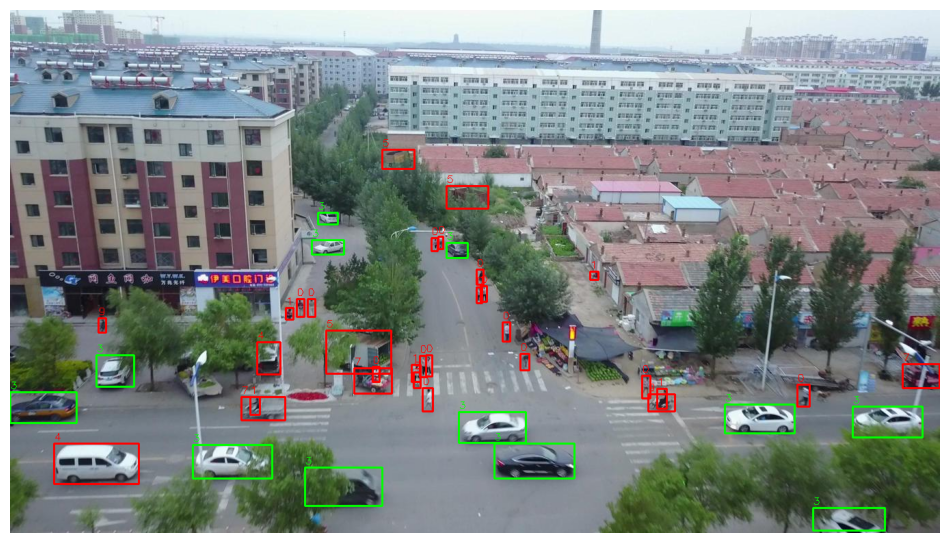

In [8]:
import cv2
import matplotlib.pyplot as plt

def draw_boxes(image_path, label_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for Matplotlib
    height, width, _ = img.shape

    # 2. Read the label file
    with open(label_path, 'r') as f:
        lines = f.readlines()

    # 3. Process each line/object
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        class_id = int(parts[0])
        x_center, y_center, w, h = map(float, parts[1:5])

        # 4. Convert normalized YOLO format to pixel coordinates
        # x_min = (x_center - width_percent/2) * img_width
        x1 = int((x_center - w / 2) * width)
        y1 = int((y_center - h / 2) * height)
        x2 = int((x_center + w / 2) * width)
        y2 = int((y_center + h / 2) * height)

        # 5. Draw the rectangle
        # Choose color based on class (Example: 3=Car/Green, 5=Truck/Red)
        color = (0, 255, 0) if class_id == 3 else (255, 0, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Optional: Add class label text
        cv2.putText(img, str(class_id), (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # 6. Display the result
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# --- Run the function ---
img_p, lbl_p = metadata[metadata["split_type"]==1].iloc[1][1], metadata[metadata["split_type"]==1].iloc[1][2]
draw_boxes(img_p, lbl_p)

# **Custom and Preprocessing Functions**

# **Dataset and Dataloader**

In [9]:
import pandas as pd
from pathlib import Path

def create_visdrone_dataframe(root_path):
    root = Path(root_path)
    data = []

    # Mapping folder names to their split integer
    splits = {
        'VisDrone2019-DET-train': 0,
        'VisDrone2019-DET-val': 1,
        'VisDrone2019-DET-test-dev': 2,
        'VisDrone2019-DET-test-challenge': 2 # Adding this in case it's needed
    }

    for folder_name, split_id in splits.items():
        img_dir = root / folder_name / 'images'
        lbl_dir = root / folder_name / 'labels'

        if not img_dir.exists():
            continue

        for img_path in img_dir.glob('*.jpg'):
            # 1. Extract image_id (e.g., "0000006" from "0000006_00159_d_0000001.jpg")
            # .stem gives the filename without .jpg
            scene_id = img_path.stem.split('_')[0]

            # 2. Construct matching label path
            label_path = lbl_dir / (img_path.stem + '.txt')

            # 3. Append data (handling cases where labels might be missing)
            data.append({
                'scene_id': scene_id,
                'image_path': str(img_path),
                'label_path': str(label_path) if label_path.exists() else None,
                'split_type': split_id
            })

    return pd.DataFrame(data)

# --- Usage ---
root_dir = "/content/visdrone-dataset/VisDrone_Dataset"
metadata = create_visdrone_dataframe(root_dir)
metadata

# Preview the results
# print(metadata.iloc[0,1])

,scene_id,image_path,label_path,split_type
0,9999953,/content/visdrone-dataset/VisDrone_Dataset/Vis...,/content/visdrone-dataset/VisDrone_Dataset/Vis...,0
1,9999950,/content/visdrone-dataset/VisDrone_Dataset/Vis...,/content/visdrone-dataset/VisDrone_Dataset/Vis...,0
2,9999962,/content/visdrone-dataset/VisDrone_Dataset/Vis...,/content/visdrone-dataset/VisDrone_Dataset/Vis...,0
3,9999955,/content/visdrone-dataset/VisDrone_Dataset/Vis...,/content/visdrone-dataset/VisDrone_Dataset/Vis...,0
4,9999999,/content/visdrone-dataset/VisDrone_Dataset/Vis...,/content/visdrone-dataset/VisDrone_Dataset/Vis...,0
...,...,...,...,...
10204,0000097,/content/visdrone-dataset/VisDrone_Dataset/Vis...,None,2
10205,0000233,/content/visdrone-dataset/VisDrone_Dataset/Vis...,None,2
10206,9999936,/content/visdrone-dataset/VisDrone_Dataset/Vis...,None,2
10207,0000319,/content/visdrone-dataset/VisDrone_Dataset/Vis...,None,2


In [10]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd

class VisDroneDataset(Dataset):
    def __init__(self, dataframe, img_size=640, is_train=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.is_train = is_train

        # --- FASTER R-CNN CHANGE ---
        # Faster R-CNN reserves Class 0 for the Background.
        # We must map Vehicles to 1 and People to 2.
        self.class_mapping = {
            0: 2, 1: 2,       # People -> Class 2
            2: -1,            # Bicycle (ignore)
            3: 1, 4: 1, 5: 1, 8: 1, # Vehicles -> Class 1
            6: -1, 7: -1, 9: -1 # Tricycles/Motors (ignore)
        }

        self.transform = self._get_transforms()

    def _get_transforms(self):
        base_transforms = [
            A.LongestMaxSize(max_size=self.img_size),
            A.PadIfNeeded(
                min_height=self.img_size,
                min_width=self.img_size,
                border_mode=cv2.BORDER_CONSTANT,
                fill=(114, 114, 114)
            )
        ]

        if self.is_train:
            aug_transforms = [
                A.RandomResizedCrop(size=(self.img_size, self.img_size), scale=(0.3, 1.0), p=0.5),
                A.SafeRotate(limit=180, p=0.5, border_mode=cv2.BORDER_CONSTANT, fill=(114, 114, 114)),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
                A.HorizontalFlip(p=0.5)
            ]
            base_transforms = aug_transforms + base_transforms

        base_transforms.extend([
            A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
            ToTensorV2()
        ])

        return A.Compose(
            base_transforms,
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2)
        )

    def _read_labels(self, label_path):
        bboxes = []
        class_labels = []
        if label_path and pd.notna(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        mapped_id = self.class_mapping.get(class_id, -1)

                        if mapped_id != -1:
                            x, y, w, h = map(float, parts[1:5])

                            xmin = x - (w / 2.0)
                            ymin = y - (h / 2.0)
                            xmax = x + (w / 2.0)
                            ymax = y + (h / 2.0)

                            xmin = np.clip(xmin, 0.0, 1.0)
                            ymin = np.clip(ymin, 0.0, 1.0)
                            xmax = np.clip(xmax, 0.0, 1.0)
                            ymax = np.clip(ymax, 0.0, 1.0)

                            new_w = xmax - xmin
                            new_h = ymax - ymin
                            new_x = xmin + (new_w / 2.0)
                            new_y = ymin + (new_h / 2.0)

                            if new_w > 0.001 and new_h > 0.001:
                                bboxes.append([new_x, new_y, new_w, new_h])
                                class_labels.append(mapped_id)

        return bboxes, class_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        bboxes, class_labels = self._read_labels(row['label_path'])

        transformed = self.transform(image=img, bboxes=bboxes, class_labels=class_labels)

        image_tensor = transformed['image']
        transformed_bboxes = transformed['bboxes']
        transformed_classes = transformed['class_labels']

        # --- FASTER R-CNN CHANGE ---
        # Faster R-CNN needs a target Dictionary with 'boxes' and 'labels'
        if len(transformed_bboxes) > 0:
            boxes = torch.tensor(transformed_bboxes, dtype=torch.float32)
            labels = torch.tensor(transformed_classes, dtype=torch.int64)

            # 1. Convert normalized YOLO [cx, cy, w, h] to absolute pixel [xmin, ymin, xmax, ymax]
            cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]

            xmin = (cx - w / 2) * self.img_size
            ymin = (cy - h / 2) * self.img_size
            xmax = (cx + w / 2) * self.img_size
            ymax = (cy + h / 2) * self.img_size

            # 2. Ensure boxes stay mathematically strictly within the image dimensions
            xmin = torch.clamp(xmin, min=0, max=self.img_size)
            ymin = torch.clamp(ymin, min=0, max=self.img_size)
            xmax = torch.clamp(xmax, min=0, max=self.img_size)
            ymax = torch.clamp(ymax, min=0, max=self.img_size)

            absolute_boxes = torch.stack((xmin, ymin, xmax, ymax), dim=1)

            # 3. Create the expected dictionary
            target = {
                "boxes": absolute_boxes,
                "labels": labels
            }
        else:
            # Handle images with no valid objects
            target = {
                "boxes": torch.empty((0, 4), dtype=torch.float32),
                "labels": torch.empty((0,), dtype=torch.int64)
            }

        return image_tensor, target


# 2. Split the metadata into Train (0) and Val (1) dataframes
train_df = metadata[metadata['split_type'] == 0]
val_df = metadata[metadata['split_type'] == 1]

# 3. Now you can initialize your datasets!
train_dataset = VisDroneDataset(train_df, img_size=640, is_train=True)
val_dataset = VisDroneDataset(val_df, img_size=640, is_train=False)

# Test it
img_tensor, target_dict = train_dataset[0]
print(target_dict["boxes"].shape)

torch.Size([18, 4])


In [11]:
import torch
from torch.utils.data import DataLoader

# --- 1. Refined Collate Function for Faster R-CNN ---
def detection_collate_fn(batch):
    """
    Custom collate function for torchvision detection models.
    It transposes the batch from a list of tuples: [(img1, tgt1), (img2, tgt2)]
    into a tuple of lists: ((img1, img2), (tgt1, tgt2)).
    """
    return tuple(zip(*batch))

# --- 2. Setup DataLoaders ---
# Faster R-CNN is memory-heavy. Batch sizes of 4 to 8 are standard for Colab/Standard GPUs.
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # Shuffle training data to improve model generalization
    num_workers=2,         # Number of CPU subprocesses for data loading
    collate_fn=detection_collate_fn,
    pin_memory=True,       # Uncomment this if you are using a GPU!
    drop_last=True         # Drops the last incomplete batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # No need to shuffle validation data
    num_workers=2,
    collate_fn=detection_collate_fn,
    pin_memory=True      # Uncomment this if you are using a GPU!
)

# --- 3. Test the DataLoader ---
# Grab one batch to verify shapes
batch_images, batch_targets = next(iter(train_loader))

print(f"Number of Images in Batch: {len(batch_images)}")
# Expected: 4 (Matching your BATCH_SIZE)

print(f"Shape of first Image: {batch_images[0].shape}")
# Expected: torch.Size([3, 640, 640])

print(f"Number of Target Dictionaries: {len(batch_targets)}")
# Expected: 4

print(f"Keys in first Target Dict: {batch_targets[0].keys()}")
# Expected: dict_keys(['boxes', 'labels'])

print(f"Boxes shape for first image: {batch_targets[0]['boxes'].shape}")
# Expected: torch.Size([N, 4]) where N is the number of objects

Number of Images in Batch: 4
Shape of first Image: torch.Size([3, 640, 640])
Number of Target Dictionaries: 4
Keys in first Target Dict: dict_keys(['boxes', 'labels'])
Boxes shape for first image: torch.Size([20, 4])


# **Model and Training**

## **Model**

In [12]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import pandas as pd



# --- 1. Model Configuration ---
class Config:
    NUM_CLASSES = 3  # 0: Background, 1: Vehicles, 2: People
    LEARNING_RATE = 0.005
    EPOCHS = 2
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dynamic Path Setup
    BASE_DIR = "/content/drive/MyDrive/ants/visdrone_faster_rcnn_results"
    SAVE_PATH = os.path.join(BASE_DIR, "best_detection_model.pth")
    LOG_PATH = os.path.join(BASE_DIR, "training_history.csv")
# Ensure directories exist
os.makedirs(Config.BASE_DIR, exist_ok=True)

# --- 2. Model Initialization ---
def get_faster_rcnn_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
        weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [13]:
# --- 3. Training & Validation Functions ---
def train_one_epoch(model, dataloader, optimizer, device):
    model.train() # Sets model to output losses
    running_loss = 0.0

    pbar = tqdm(dataloader, desc="Training", unit="batch", leave=False)
    for images, targets in pbar:
        # Move lists of tensors/dicts to device
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        # Forward pass returns a dictionary of various losses (classification, bounding box, etc.)
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return running_loss / len(dataloader)

def validate(model, dataloader, device):
    # CRITICAL: Faster R-CNN only calculates losses if it remains in train() mode.
    # If we switch to eval(), it outputs final bounding boxes instead of loss calculations.
    model.train()
    running_loss = 0.0

    # We use torch.no_grad() to ensure weights are NOT updated during validation
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validating", unit="batch", leave=False)
        for images, targets in pbar:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())

            running_loss += loss.item()

    return running_loss / len(dataloader)

# --- 4. Main Training Controller ---
def run_training(train_loader, val_loader):
    print(f"🚀 Starting Faster R-CNN Training on {Config.DEVICE}...")

    # Initialize Model
    model = get_faster_rcnn_model(Config.NUM_CLASSES).to(Config.DEVICE)

    # Optimizer & Scheduler
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=Config.LEARNING_RATE, momentum=0.9, weight_decay=0.0005)

    # Notice we switched to ReduceLROnPlateau to match your advanced loop logic
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = []
    best_val_loss = float('inf') # We track lowest loss instead of highest accuracy

    for epoch in range(Config.EPOCHS):
        # Run Train and Val loops
        train_loss = train_one_epoch(model, train_loader, optimizer, Config.DEVICE)
        val_loss = validate(model, val_loader, Config.DEVICE)

        # Update Scheduler based on validation loss
        scheduler.step(val_loss)

        # Log entry for CSV
        log_entry = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'lr': optimizer.param_groups[0]['lr']
        }
        history.append(log_entry)
        pd.DataFrame(history).to_csv(Config.LOG_PATH, index=False)

        # Print Output Console Formatting
        print(f"Ep [{epoch+1}/{Config.EPOCHS}] "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        # Best Model Saving (Saves state dict based on lowest Validation Loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss
            }, Config.SAVE_PATH)
            print(f"⭐ Best Model Updated (Val Loss: {val_loss:.4f})")

    print(f"✅ Finished. Metrics saved to {Config.LOG_PATH}")

# --- 5. EXECUTION ---
# Ensure your train_loader and val_loader are already defined before running this!
run_training(train_loader, val_loader)

🚀 Starting Faster R-CNN Training on cuda...


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100%|██████████| 167M/167M [00:01<00:00, 133MB/s]


Ep [1/2] Train Loss: 1.0134 | Val Loss: 0.9166 | LR: 5.00e-03
⭐ Best Model Updated (Val Loss: 0.9166)


Ep [2/2] Train Loss: 0.9171 | Val Loss: 0.8603 | LR: 5.00e-03
⭐ Best Model Updated (Val Loss: 0.8603)
✅ Finished. Metrics saved to /content/drive/MyDrive/ants/visdrone_faster_rcnn_results/training_history.csv


# **Inferencing and Evaluation**

In [14]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as T

# --- Configuration & Labels ---
CLASS_NAMES = ['__background__', 'Vehicle', 'Person']
COLORS = [(0, 0, 0), (255, 0, 0), (0, 255, 0)] # Red for Vehicles, Green for People

def load_best_model(path, device):
    # Use your previously defined initialization function
    model = get_faster_rcnn_model(Config.NUM_CLASSES)
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']} with Val Loss: {checkpoint['val_loss']:.4f}")
    return model

device = Config.DEVICE
model = load_best_model(Config.SAVE_PATH, device)

/tmp/ipykernel_7434/3866518209.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


✅ Loaded best model from epoch 1 with Val Loss: 0.8603


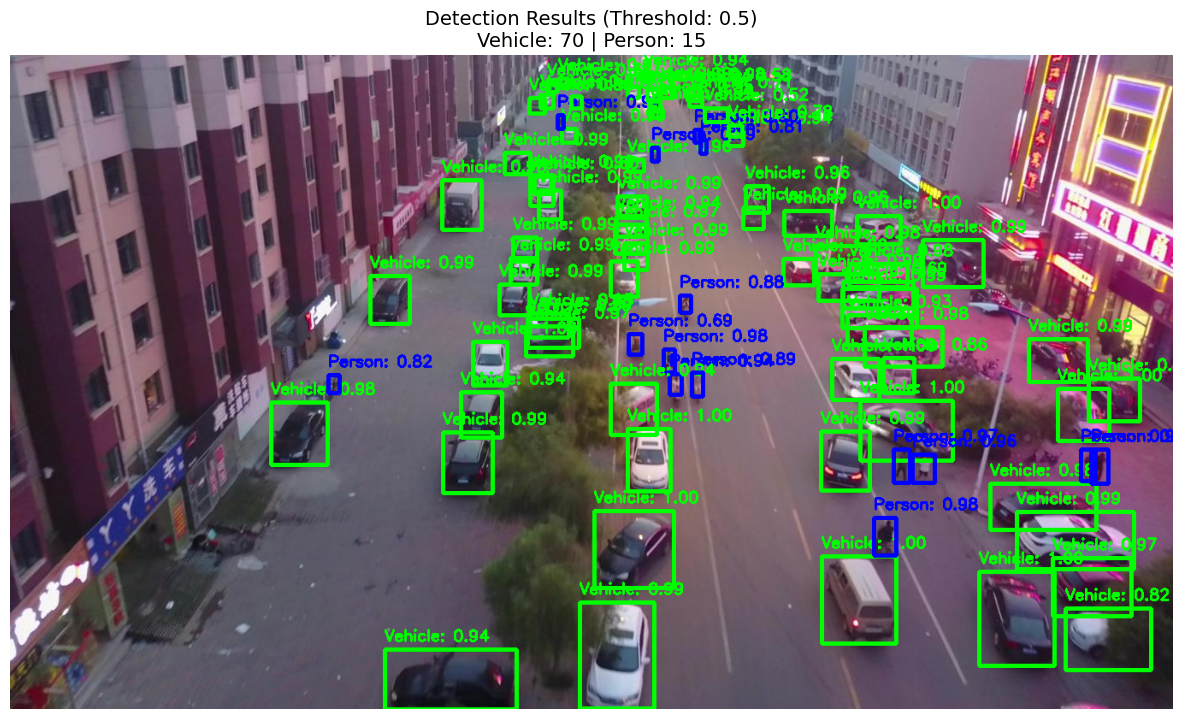

In [15]:
import torch
import torchvision
import torchvision.transforms as T
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. Setup Labels & Colors (Must match your Dataset mapping) ---
# 0: Background (Required by Faster R-CNN)
# 1: Vehicles (mapped from 3, 4, 5, 8)
# 2: People (mapped from 0, 1)
CLASS_NAMES = ["__background__", "Vehicle", "Person"]
COLORS = [(0, 0, 0), (0, 255, 0), (255, 0, 0)] # BGR: Black, Green (Vehicles), Red (People)

def visualize_predictions(image_path, model, device, threshold=0.5):
    # Load and transform image
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return

    img_orig = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(img_orig).to(device)

    # Set model to evaluation mode
    model.eval()

    # Prediction
    with torch.no_grad():
        # Faster R-CNN expects a list of tensors
        prediction = model([img_tensor])

    # Move results to CPU
    boxes = prediction[0]['boxes'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()

    # Filter by threshold
    mask = scores > threshold
    boxes = boxes[mask]
    labels = labels[mask]
    scores = scores[mask]

    # --- Counting Logic ---
    counts = {name: 0 for name in CLASS_NAMES if name != '__background__'}

    # Plotting
    img_draw = np.array(img_orig)
    img_draw = cv2.cvtColor(img_draw, cv2.COLOR_RGB2BGR) # Convert to BGR for OpenCV

    for box, label, score in zip(boxes, labels, scores):
        name = CLASS_NAMES[label]
        counts[name] += 1

        # Draw Bounding Box
        color = COLORS[label]
        cv2.rectangle(img_draw, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), color, 3)

        # Draw Label + Score
        text = f"{name}: {score:.2f}"
        cv2.putText(img_draw, text, (int(box[0]), int(box[1]-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Convert back to RGB for Matplotlib display
    img_final = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    # --- Result Summary ---
    plt.figure(figsize=(15, 10))
    plt.imshow(img_final)

    summary_text = " | ".join([f"{k}: {v}" for k, v in counts.items()])
    plt.title(f"Detection Results (Threshold: {threshold})\n{summary_text}", fontsize=14)
    plt.axis('off')
    plt.show()

    return counts

# --- 2. Run the Prediction ---
# Make sure your model is loaded with your trained weights before running this!
# model.load_state_dict(torch.load("visdrone_faster_rcnn_final.pth"))

test_image = "/content/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/0000104_01170_d_0000060.jpg"
counts = visualize_predictions(test_image, model, device)